# 🌡️ Predicción de Temperatura Futura usando RandomForestRegressor

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


In [2]:
# Cargar dataset limpio generado previamente
df = pd.read_csv("weather_data.csv")

# Explicitly convert timestamp to datetime with ISO8601 format
df["timestamp"] = pd.to_datetime(df["timestamp"], format='ISO8601')  # Use ISO8601 format for parsing

# Extract time features
df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.dayofweek
df["minute"] = df["timestamp"].dt.minute

# Crear variables objetivo
df["temp_plus_1h"] = df["temperature"].shift(-12)
df["temp_plus_3h"] = df["temperature"].shift(-36)
df.dropna(subset=["temp_plus_1h", "temp_plus_3h"], inplace=True)

df.head()


,timestamp,temperature,dew_point,humidity,wind_speed,pressure,uv_index,hour,dayofweek,minute,pred_temp_plus_1h,pred_temp_plus_3h,temp_plus_1h,temp_plus_3h
0,2025-06-01 19:15:48.514288,60.0,48.0,64.0,8.51,29.77,0.9,19,6,15,NaN,NaN,60.0,60.0
1,2025-06-01 19:15:58.511898,60.0,48.0,64.0,8.51,29.77,0.9,19,6,15,NaN,NaN,60.0,60.0
2,2025-06-01 19:16:08.513850,60.0,48.0,64.0,8.51,29.77,0.9,19,6,16,NaN,NaN,60.0,60.0
3,2025-06-01 19:16:18.511339,60.0,48.0,64.0,8.51,29.77,0.9,19,6,16,NaN,NaN,60.0,60.0
4,2025-06-01 19:16:28.543192,60.0,48.0,64.0,8.51,29.77,0.9,19,6,16,NaN,NaN,60.0,60.0


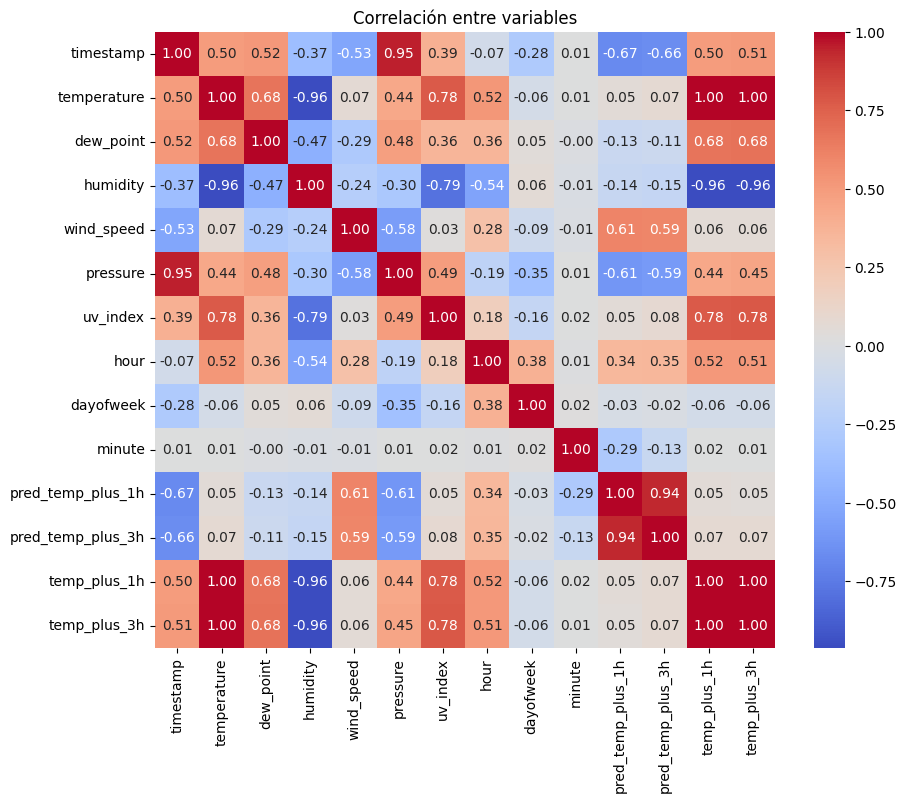

In [3]:
# Ver correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre variables")
plt.show()


In [4]:
features = ["temperature", "dew_point", "humidity", "wind_speed", "pressure", "uv_index", "hour", "dayofweek", "minute"]
X = df[features]
y1 = df["temp_plus_1h"]
y3 = df["temp_plus_3h"]


In [5]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y1, test_size=0.2, random_state=42)
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y3, test_size=0.2, random_state=42)


In [6]:
model1 = RandomForestRegressor(n_estimators=100, random_state=42)
model1.fit(X_train1, y_train1)

model3 = RandomForestRegressor(n_estimators=100, random_state=42)
model3.fit(X_train3, y_train3)


RandomForestRegressor(random_state=42)

🔍 Predicción +1h - MSE: 0.01 | R²: 1.00


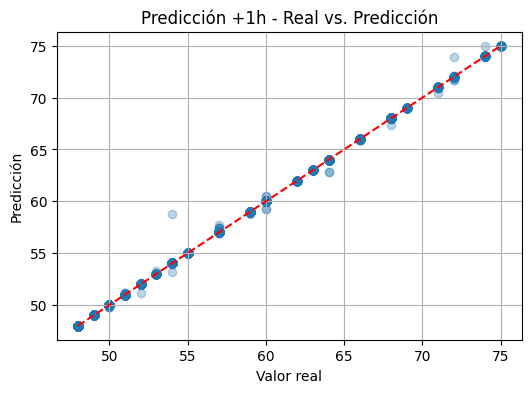

🔍 Predicción +3h - MSE: 0.01 | R²: 1.00


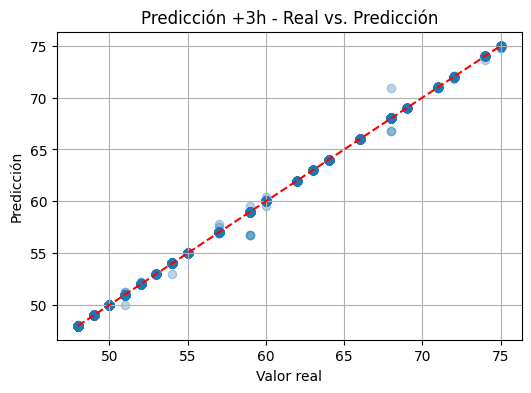

In [7]:
def evaluate(model, X_test, y_test, name):
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"🔍 {name} - MSE: {mse:.2f} | R²: {r2:.2f}")
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, preds, alpha=0.3)
    plt.xlabel("Valor real")
    plt.ylabel("Predicción")
    plt.title(f"{name} - Real vs. Predicción")
    plt.grid(True)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    plt.show()

evaluate(model1, X_test1, y_test1, "Predicción +1h")
evaluate(model3, X_test3, y_test3, "Predicción +3h")


In [8]:
joblib.dump(model1, "modelo_temp_plus_1h.pkl")
joblib.dump(model3, "modelo_temp_plus_3h.pkl")
print("✅ Modelos guardados como .pkl")


✅ Modelos guardados como .pkl
